# 🔵 AT | Inteligência Artificial: Model LifeCycle

**Bem-vindos ao AT!**

Em cada Parte você utilizará um dos seguintes conjunto de dados:

O Dataset de Funcionários contém informações sobre funcionários de uma grande empresa que foram empregados ao longo dos anos. O atributo alvo (target) é aquele que indica se o funcionário irá sair ou não da empresa.

* [Dataset de Funcionários](https://www.kaggle.com/datasets/tawfikelmetwally/employee-dataset)


O Dataset de Expectativa de Vida contém informações coletadas da Organização Mundial da Saúde sobre índices de saúde para diferentes países em diferentes períodos. O atributo alvo (target) do dataset é aquele que indica a expectativa de vida do país.

* [Dataset de Expectativa de Vida](https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who/data)

**Instruções de entrega:**

* Todas as respostas (textuais ou código-fonte) devem estar contidas em um notebook do Google Colab.
* O nome do notebook deve estar no formato nome_sobrenome_DR1_AT.
* Respostas textuais devem ser respondidas em markdowns e respostas de código-fonte devem ser respondidas em seções de código-fonte no Google Colab.
* Identifique claramente cada exercício e sua resposta.
* Certifique-se que qualquer código-fonte esteja executando corretamente no Google Colab.
* No moodle, apenas um pdf deve ser postado contendo o link para o Google Colab.
* Você deve fornecer um único link para um Notebook do Google Colab contendo as duas partes do AT.

**Importante:**

* O conjunto de dados deve ser preparado adequadamente (como visto em aula) antes de construir o modelo. Essa preparação inclui remover exemplos com valores nulos e substituição de valores categóricos por valores numéricos.
* Os exercícios não são uma descrição de passos sequenciais a serem seguidos, mas sim, um conjunto de tarefas a serem realizadas. Isso significa que você deve realizar todas as tarefas, independente da ordem descrita abaixo.
* Você deve utilizar as funções e bibliotecas vistas em sala de aula. Quaisquer outras funções ou bibliotecas utilizadas requerem uma explicação detalhada para considerar o exercício correto.

## ⤵️ Imports

In [82]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import kagglehub

In [83]:
path_employee_df = kagglehub.dataset_download("tawfikelmetwally/employee-dataset")
path_life_expectancy = kagglehub.dataset_download("kumarajarshi/life-expectancy-who")

Using Colab cache for faster access to the 'employee-dataset' dataset.
Using Colab cache for faster access to the 'life-expectancy-who' dataset.


## Parte 1 | Avaliação de Três fases para Classificador Binário

#### 📍 **Exercício 01:**
Crie um DataFrame pandas a partir do Dataset de Funcionários e prepare-o para utilização, removendo todos os exemplos que contenham valores de atributo nulos e substituindo quaisquer valores nominais por valores numéricos.

In [84]:
employee_df = pd.read_csv(f'{path_employee_df}/Employee.csv')
employee_df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


💡 Remoção de valores nulos

In [85]:
employee_df.isna().sum()

,0
Education,0
JoiningYear,0
City,0
PaymentTier,0
Age,0
Gender,0
EverBenched,0
ExperienceInCurrentDomain,0
LeaveOrNot,0


**🗣️ Comentário:**

Não existe nenhum valor nulo neste dataset.

💡 Vetorização de variáveis categóricas

In [86]:
categorical_columns = ['Education', 'City', 'Gender']

for col in categorical_columns:
  print(f'{col} | Categorias: {employee_df[col].nunique()}')

encoder = OneHotEncoder(sparse_output=False, drop='first')

encoded_columns = encoder.fit_transform(employee_df[categorical_columns])
encoded_employee_df = pd.DataFrame(encoded_columns, columns=encoder.get_feature_names_out())
encoded_employee_df = pd.concat([employee_df.drop(categorical_columns, axis=1), encoded_employee_df], axis=1)

Education | Categorias: 3
City | Categorias: 3
Gender | Categorias: 2


In [87]:
everbenched_map = {
    'No': 0,
    'Yes': 1
}

encoded_employee_df['EverBenched'] = encoded_employee_df['EverBenched'].map(everbenched_map)

In [88]:
for col in encoded_employee_df.columns:
  print(f'{col:25} | {encoded_employee_df[col].dtypes}')

JoiningYear               | int64
PaymentTier               | int64
Age                       | int64
EverBenched               | int64
ExperienceInCurrentDomain | int64
LeaveOrNot                | int64
Education_Masters         | float64
Education_PHD             | float64
City_New Delhi            | float64
City_Pune                 | float64
Gender_Male               | float64


**🗣️ Comentário:**

Vetorizei as variáveis categóricas com o método OneHotEncoder. Optei por remover a primeirca coluna (torná-la implícita no modelo), para reduzir o número de dimensões no df.

Para a variável 'EverBenched', como possuia valores booleanos (Y e N), realizei o map dos valores para:
* No -> 0
* Yes -> 1

💡 Normalização das variáveis numéricas

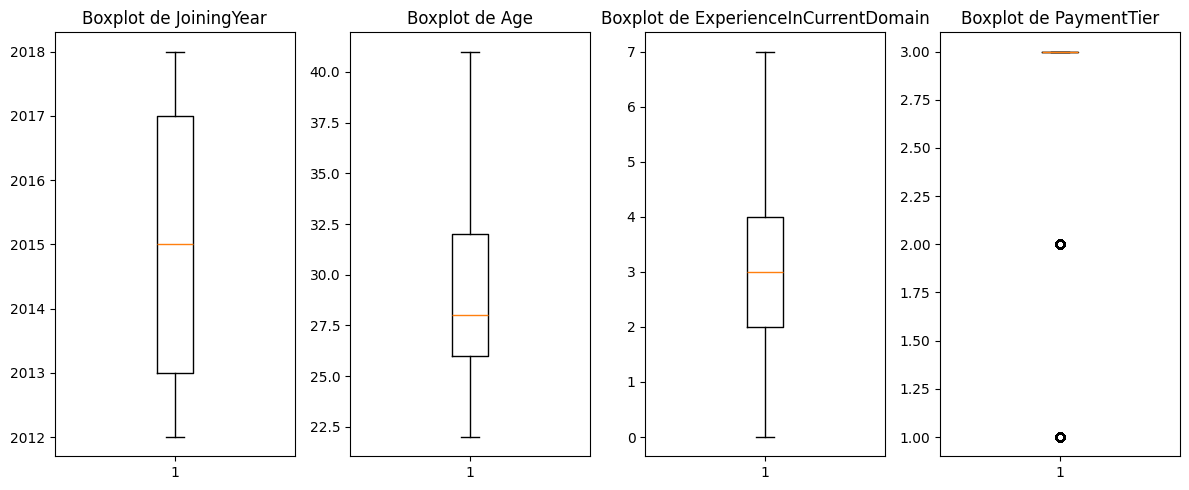

In [89]:
numeric_columns = ['JoiningYear', 'Age', 'ExperienceInCurrentDomain', 'PaymentTier']

plt.figure(figsize=(12, 5))
for col in numeric_columns:
  plt.subplot(1, 4, numeric_columns.index(col) + 1)
  plt.boxplot(encoded_employee_df[col])
  plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

In [90]:
scaler = StandardScaler()

encoded_employee_df[numeric_columns] = scaler.fit_transform(encoded_employee_df[numeric_columns])

**🗣️ Comentário:**

Variáveis numéricas normalizadas pelo método StandardScaler.

In [91]:
encoded_employee_df.head()

,JoiningYear,PaymentTier,Age,EverBenched,ExperienceInCurrentDomain,LeaveOrNot,Education_Masters,Education_PHD,City_New Delhi,City_Pune,Gender_Male
0,1.039638,0.537503,0.954645,0,-1.864901,0,0.0,0.0,0.0,0.0,1.0
1,-1.107233,-3.025177,-0.288732,0,0.060554,1,0.0,0.0,0.0,1.0,0.0
2,-0.570515,0.537503,1.783563,0,-0.581264,0,0.0,0.0,1.0,0.0,0.0
3,0.502921,0.537503,-0.495961,0,1.344191,1,1.0,0.0,0.0,0.0,1.0
4,1.039638,0.537503,-1.117650,1,-0.581264,1,1.0,0.0,0.0,1.0,1.0


***

#### 📍 **Exercício 02:**
Divida o Dataset de de Funcionários em dois conjuntos: **conjunto de treinamento (80%)** e **conjunto de teste (20%)**.

In [92]:
train_f, test_f, train_t, test_t = train_test_split(
    encoded_employee_df.drop('LeaveOrNot', axis=1),
    encoded_employee_df['LeaveOrNot'],
    stratify=encoded_employee_df['LeaveOrNot'],
    test_size=0.2,
    random_state=42
)

***

#### 📍 **Exercício 03:**
Realize Validação Cruzada de 20-dobras com embaralhamento (mistura) de amostras utilizando o conjunto de treinamento. Utilize o Classificador KNN e realize a Validação Cruzada de 20-dobras para diferentes valores do parâmetro 𝑘
 indo de 2 até 200 em intervalos de 10 em 10.

#### 📍 **Exercício 04:**
Calcule o valor médio de Acurácia, Precisão e Recall para as 20 dobras para cada valor de 𝑘.

**Obs.:** Para cada métrica você deve armazenar 𝑘
 valores médios diferentes, correspondendo aos 𝐾
 modelos K-NN.

In [93]:
scores_list = []

k_values = np.arange(2, 200, 10, dtype=int)
kf = KFold(n_splits=20, shuffle=True)

In [94]:
for k in k_values:
  knn = KNeighborsClassifier(n_neighbors=k)
  scores = cross_validate(knn, train_f, train_t, cv=kf, scoring=['accuracy', 'precision', 'recall', 'f1'])
  scores_list.append({
        'k': k,
        'accuracy': scores['test_accuracy'].mean(),
        'precision': scores['test_precision'].mean(),
        'recall': scores['test_recall'].mean(),
        'f1': scores['test_f1'].mean(),
        'std_accuracy': scores['test_accuracy'].std(),
        'scores_raw': scores
    })

**🗣️ Comentário:**

Criado o modelo KNN e feita a validação cruzada, com 20 folds, onde é calculada as métricas:
* Acurácia
* Precisão
* Recall
* F1-Score

Adicionei tudo em um dicionário e criei um `pd.DataFrame` com os dados. Dessa forma, facilita a criação de plots e a identificação do melhor valor de k_neighbors.

***

#### 📍 **Exercício 05:**
Encontre o valor de 𝑘 que apresenta o melhor desempenho de Acurácia.

In [95]:
scores_df = pd.DataFrame(scores_list)
scores_df.sort_values(by='accuracy', ascending=False).head(3)[['k','accuracy']]

,k,accuracy
1,12,0.805207
0,2,0.803338
4,42,0.790688


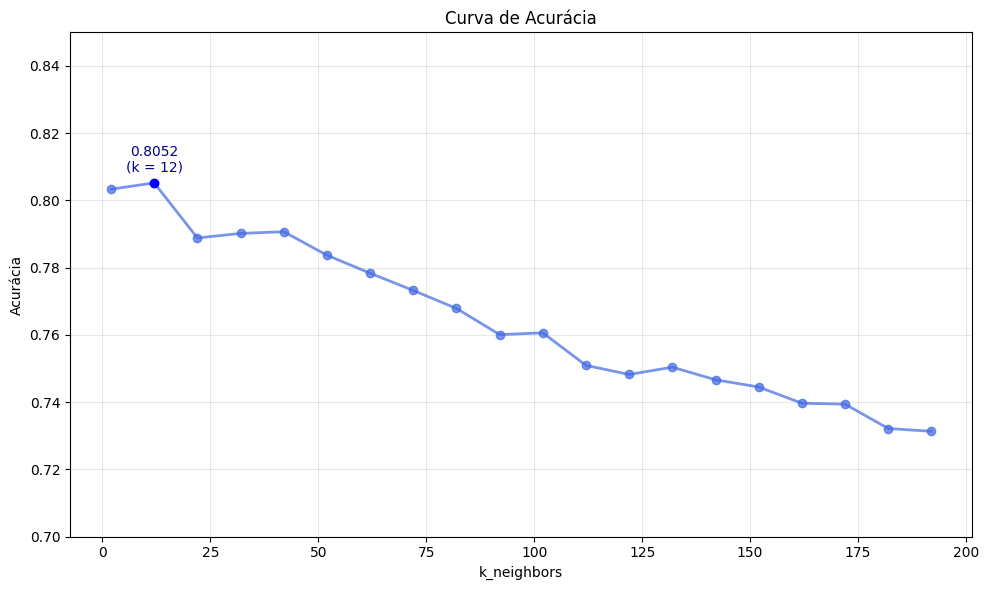

In [96]:
plt.figure(figsize=(10, 6))

plt.plot(
    scores_df['k'],
    scores_df['accuracy'],
    color='royalblue',
    linewidth=2,
    marker='o',
    alpha=0.7
)

top = scores_df.nlargest(1, 'accuracy')
x = top['k'].values[0]
y = top['accuracy'].values[0]

# Identificando o melhor valor de k_neighbors
plt.plot(
    x,
    y,
    color='blue',
    marker='o',
)

plt.annotate(
  f'{y:.4f}\n(k = {x})',
  (x, y),
  xytext=(0, 8),
  textcoords='offset points',
  color='darkblue',
  ha='center'
)

plt.title('Curva de Acurácia')
plt.xlabel('k_neighbors')
plt.ylabel('Acurácia')
plt.ylim(0.70, 0.85)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**🗣️ Comentário:**

O melhor valor para k_neighbors, baseado na acurácia, é **k = 12, com cerca de 80,52%**.

***

#### 📍 **Exercício 06:**
Treine um modelo Classificador KNN com o valor de 𝑘 encontrado e gere dois gráficos com a Curva Precision-Recall e Curva de ROC.

In [97]:
best_k = scores_df.nlargest(1, 'accuracy')['k'].values[0]

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(train_f, train_t)
predicted = knn.predict_proba(test_f)[:,1]

In [98]:
precision_PR, recall_PR, threshold_PR = precision_recall_curve(test_t, predicted)

fpr, tpr, thresholds = roc_curve(test_t, predicted)

/tmp/ipykernel_3766/1090033132.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_3766/1090033132.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


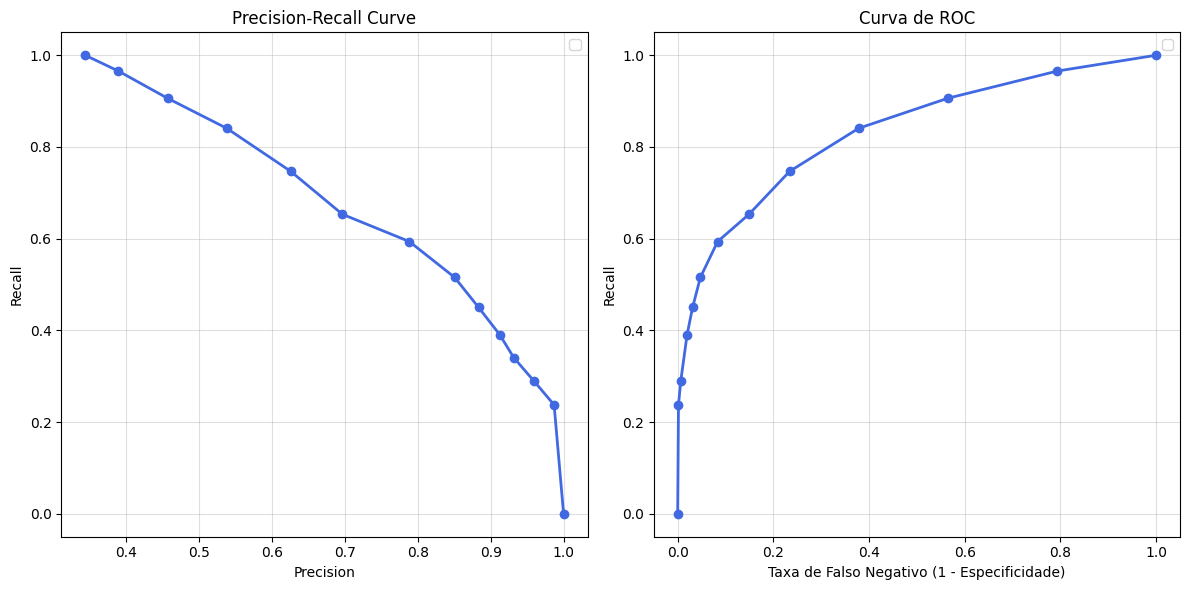

In [99]:
plt.figure(figsize=(12, 6))

# Precision-Recall Curve
plt.subplot(1, 2, 1)
plt.plot(
  precision_PR,
  recall_PR,
  marker='o',
  color='royalblue',
  linewidth=2
)
plt.title('Precision-Recall Curve')
plt.xlabel('Precision')
plt.ylabel('Recall')
plt.legend()
plt.grid(alpha=0.4)

# ROC Curve
plt.subplot(1, 2, 2)
plt.plot(
  fpr,
  tpr,
  marker='o',
  color='royalblue',
  linewidth=2
)
plt.title('Curva de ROC')
plt.xlabel('Taxa de Falso Negativo (1 - Especificidade)')
plt.ylabel('Recall')
plt.legend()
plt.grid(alpha=0.4)

plt.tight_layout()
plt.show()

***

#### 📍 **Exercício 07:**
Descreva os gráficos Precision-Recall e Curva de ROC. Discuta o ponto ideal, e o tradeoff entre as métricas e relacione com os dados do Dataset de Funcionário.

**🗣️ Comentário:**

* Recall mede a capacidade do modelo de identificar os positivos reais
* Precision mede a confiabilidade das previsões positivas

Na curva **Precision-Recall**, observa-se um trade-off entre essas métricas: aumentar o recall tende a reduzir a precision, pois o modelo passa a classificar mais instâncias como positivas, aumentando os falsos positivos.

Trazendo para o dataset de funcionário:
Quanto maior o recall e menor a precision, o modelo classificaria mais positivos, acertando vedadeiros positivos, mas classificando, também, falsos positivos.

O ponto ideal seria precision ~ 0.8 e recall ~ 0.6, onde o modelo mantém boa capacidade de detecção sem comprometer a precisão.

Na curva **ROC**, tem-se a relação entre a taxa de verdadeiros positivos (recall) e a taxa de falsos positivos (inverso da especificidade).

O ponto ideal é aquele mais próximo do canto superior esquerdo, com recall ~ 0.8 e taxa de FN ~ 0.2.

***

#### 📍 **Exercício 08:**
Qual valor de limiar (threshold) de decisão que maximiza o equilíbrio entre as métricas Precision-Recall? Qual valor de limiar (threshold) de decisão que maximiza o equilíbrio entre as métricas Recall e Inverso da Especificidade?

In [100]:
# Precision-Recall
f1_scores = 2 * (precision_PR * recall_PR) / (precision_PR + recall_PR)
best_idx = np.argmax(f1_scores)
best_threshold_pr = thresholds[best_idx]

print("Melhor threshold (PR):", best_threshold_pr)

# ROC
youden_index = tpr - fpr

best_idx_roc = np.argmax(youden_index)
best_threshold_roc = thresholds[best_idx_roc]

print("Melhor threshold (ROC):", best_threshold_roc)

Melhor threshold (PR): 0.6666666666666666
Melhor threshold (ROC): 0.3333333333333333


**🗣️ Comentário:**

Utilizando as técnicas F1-Score e youden_index, encontrei os melhores valores para os thresholds para o cálculo das métricas Precision-Recall e curva de ROC, respectivamente.

***

## Parte 2 | Busca Hiperparamétrica, Underfitting e Overfitting

In [101]:
life_expectancy_df = pd.read_csv(f'{path_life_expectancy}/Life Expectancy Data.csv')
life_expectancy_df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


#### 📍 **Exercício 01:**
Realize a Busca Hiperparamétrica com as seguintes características para o Dataset de Expectativa de Vida:
* Validação Cruzada de 20-dobras.
* Embaralhamento de amostras.
* Modelo Regressor KNN.
* Variação do 𝑘 para os seguintes valores: [5, 25, 50, 75, 100, 125, 150, 175, 200].
* Função de perda: negação do erro absoluto médio.

#### 📍 **Exercício 02:**
Colete os valores das 20 dobras de **score do conjunto de teste, score do conjunto de treinamento.**

#### 📍 **Exercício 03:**
Calcule a média dos valores das dobras para cada valor 𝑘 e armazene nos vetores **teste_score_means** e **treino_score_means**.

#### 📍 **Exercício 04:**
Calcule a variância dos valores das dobras para cada valor 𝑘 e armazene nos vetores **teste_score_vars** e **treino_score_vars**.

In [102]:
kfolds = KFold(n_splits=20, shuffle=True)
k_values = [5, 25, 50, 75, 100, 125, 150, 175, 200]

treino_score_means = []
teste_score_means = []

treino_score_vars = []
teste_score_vars = []

for k in k_values:
  knn = KNeighborsRegressor(n_neighbors=k)
  scores = cross_validate(
    knn,
    train_f,
    train_t,
    cv=kfolds,
    scoring='neg_mean_absolute_error',
    return_train_score=True
  )

  train_scores = -scores['train_score']
  treino_score_means.append(train_scores.mean())
  treino_score_vars.append(train_scores.var())

  test_scores = -scores['test_score']
  teste_score_means.append(test_scores.mean())
  teste_score_vars.append(test_scores.var())

***

#### 📍 **Exercício 05:**
Plote um Gráfico de Dispersão (Scatter Plot) em que no eixo-x estão os valores de 𝑘 e no eixo-y os valores de variância para os conjuntos de teste e treinamento.

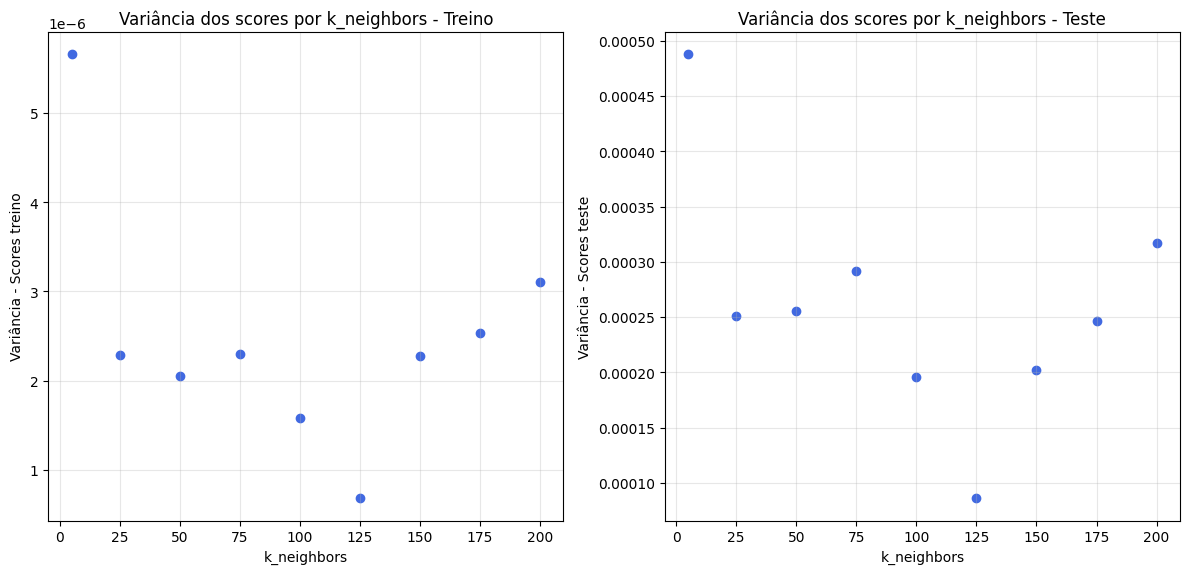

In [103]:
plt.figure(figsize=(12, 6))

#Treino
plt.subplot(1, 2, 1)
plt.scatter(
  k_values,
  treino_score_vars,
  color='royalblue'
)
plt.title('Variância dos scores por k_neighbors - Treino')
plt.xlabel('k_neighbors')
plt.ylabel('Variância - Scores treino')
plt.grid(alpha=0.3)

# Teste
plt.subplot(1, 2, 2)
plt.scatter(
  k_values,
  teste_score_vars,
  color='royalblue',
)
plt.title('Variância dos scores por k_neighbors - Teste')
plt.xlabel('k_neighbors')
plt.ylabel('Variância - Scores teste')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

***

#### 📍 **Exercício 06:**
Plote um Gráfico de Linha em que no eixo-x estão os valores de 𝑘 e no eixo-y estão os valores de média dos scores para os conjuntos de teste e treinamento.

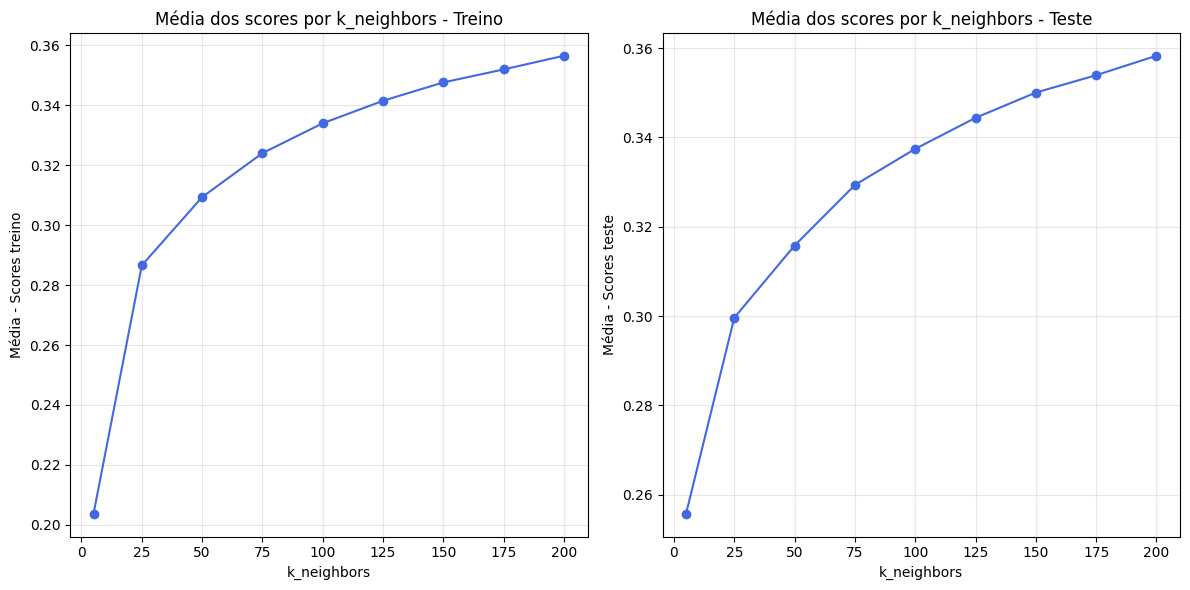

In [104]:
plt.figure(figsize=(12, 6))

#Treino
plt.subplot(1, 2, 1)
plt.plot(
  k_values,
  treino_score_means,
  color='royalblue',
  marker='o'
)
plt.title('Média dos scores por k_neighbors - Treino')
plt.xlabel('k_neighbors')
plt.ylabel('Média - Scores treino')
plt.grid(alpha=0.3)

# Teste
plt.subplot(1, 2, 2)
plt.plot(
  k_values,
  teste_score_means,
  color='royalblue',
  marker='o'
)
plt.title('Média dos scores por k_neighbors - Teste')
plt.xlabel('k_neighbors')
plt.ylabel('Média - Scores teste')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

***

#### 📍 **Exercício 07:**
A partir dos gráficos, responda: Para algum valor de 𝑘 ocorreu overfitting? Para algum valor de 𝑘 ocorreu underfitting? Justifique sua resposta com dados do gráfico.

**🗣️ Comentário:**

**Overfitting**

O overfitting acontece, geralmente, para os valores mais baixos de k_neighbors. Aqui também ocorrêu!

Quando observamos, lado a lado, a variância do modelo onde o k = 5, percebemos que o modelo tende a ter um erro maior nos dados de teste.
| | k=5 |
| - | - |
| Treino | ~0.0000053 |
| Teste | ~0.00044 |

Percebe-se uma diferença grande, o que caracteriza **overfitting**.

**Underfitting**

Para valores altos de k, observa-se underfitting, pois tanto o erro de treino quanto o de teste são altos e próximos, indicando que o modelo não consegue capturar adequadamente os padrões dos dados.

| | k=200 |
| - | - |
| Treino | ~0.0000031 |
| Teste | ~0.00032 |